In [113]:
import os
from dotenv import load_dotenv

load_dotenv()


os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')



In [114]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter


In [115]:
urls = [
    "https://docs.langchain.com/oss/python/langgraph/overview",
    "https://docs.langchain.com/oss/python/langgraph/workflows-agents",
    "https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api"
]

docs = [WebBaseLoader(url).load() for url in urls]
docs

[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainSkip to main contentDocs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceDurable executionStreamingInterruptsTime travelMemorySubgraphsProductionApplication structureTestLangSmith StudioAgent Chat UILangSmith DeploymentLangSmith ObservabilityFrontendOverviewGraph ExecutionLangGraph APIsGraph APIFunctional APIRuntimeOn this page InstallCore benefitsLangGraph ecosystemAcknowledgementsLangGraph overviewCopy pageGain control wit

In [116]:
doc_list = [item for sublist in docs for item in sublist]
doc_list

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainSkip to main contentDocs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceDurable executionStreamingInterruptsTime travelMemorySubgraphsProductionApplication structureTestLangSmith StudioAgent Chat UILangSmith DeploymentLangSmith ObservabilityFrontendOverviewGraph ExecutionLangGraph APIsGraph APIFunctional APIRuntimeOn this page InstallCore benefitsLangGraph ecosystemAcknowledgementsLangGraph overviewCopy pageGain control with

In [117]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
doc_splits = text_splitter.split_documents(documents=doc_list)

In [118]:
vectorstore = FAISS.from_documents(
    documents=doc_splits,
    embedding=OpenAIEmbeddings()
)
retriever = vectorstore.as_retriever()

In [119]:
retriever.invoke("What is langgraph?")

[Document(id='4851fd49-cebc-4be9-bf43-4c3b4335e85e', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph is a low-level orchestration framework and runtime for building, managing, and deploying long-running, stateful agents.'),
 Document(id='31bf26d5-ed55-4c51-a2ed-95cdbcdd3651', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainSkip to main contentDocs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewDeep AgentsLangChainLangGraphIntegrationsLearnReference

In [120]:
from langchain_core.tools.retriever import create_retriever_tool
retriever_tool = create_retriever_tool(
    retriever,
    "retriever_vector_db_blog",
    "Search and Run information about Langgraph"
)

In [121]:
retriever_tool

StructuredTool(name='retriever_vector_db_blog', description='Search and Run information about Langgraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x0000022985164220>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x0000022985166700>)

In [122]:
# Langchain blogs - Seperate vector DB
langchain_urls = [
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/langchain/rag",
    "https://docs.langchain.com/oss/python/langchain/sql-agent"
]

langchain_docs = [WebBaseLoader(url).load() for url in urls]


In [123]:
langchain_doc_list = [item for sublist in langchain_docs for item in sublist]

text_splitter_langchain = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
langchain_doc_splits = text_splitter_langchain.split_documents(langchain_doc_list)

vectorstore_langchain = FAISS.from_documents(
    langchain_doc_splits,
    embedding=OpenAIEmbeddings()
)

In [124]:
retriever_langchain = vectorstore_langchain.as_retriever()

In [125]:
from langchain_core.tools.retriever import create_retriever_tool

retriever_tool_langchain = create_retriever_tool(
    retriever_langchain,
    "retriever_vector_langchain_blog",
    "Search and run information about langchain"
)

In [126]:
tools = [retriever_tool, retriever_tool_langchain]

In [127]:
from typing import TypedDict, Annotated, Sequence
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage


class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


In [128]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3-32b")


In [130]:
def agent(state: State):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using retriever tool or simply end.

    Args:
        state (messages): The current state
    Returns:
        dict: The updated state with ahent response appended to the message 
    """
    print("------CALL AGENT-------")
    messages = state['messages']
    llm_with_tools = llm.bind_tools(tools=tools)
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


In [131]:
from langchain_classic import hub
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from typing import Literal
from pydantic import BaseModel, Field
# Edges Yes/No
def grade_document(state: State) -> Literal["generate", "rewrite"]:
    """
    Determine whether the retrieved documents are relevant to the questions.

    Args:
        state(messages): The current state
    
    Returns:
        str: A decision whether the document are relevant or not.  
    """
    print("----Check Relevence-----")
    # Data Model
    class grade(BaseModel):
        """Binary score for relevance check."""
        binary_score: str = Field(description="Relevence score 'yes' or 'no'")

    llm_with_structure = llm.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""
        You are a grader assessing relevance of retrieved document to a user question.
        Here is the retrieved document: \n\n{context}\n\n
        Here is the user question: {question} \n

        If the document conatins keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.
        """,
        input_variables=["context", "question"]
    )

    # chain
    chain = prompt | llm_with_structure

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("--------DECISION: DOCS RELEVANT--------")
        return "generate"
    else:
        print("--------DECISION: DOCS NOT RELEVANT----------")
        print(score)
        return "rewrite"

In [132]:
def generate(state: State):
    """
    Generate Answer

    Args:
        state (messages): The current state

    Returns:
        dict: The updated message
    """
    print("-----GENERATE--------")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = hub.pull("rlm/rag-prompt")

    model = ChatGroq(model="qwen/qwen3-32b")

    # pre processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = prompt | model | StrOutputParser()

    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [133]:
def rewrite(state: State):
    """
    Transform query to produce a better question.
    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question 
    """
    print("----TRANSFORM QUERY-------")
    messages = state['messages']
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f"""
                Look at the input and try to reason about the underlying semantic intent / meaning. \n
                Here is the initial question:
                \n ----- \n
                {question}
                \n ----- \n
                Formulate an improved question.
            """
        )
    ]

    model = ChatGroq(model="qwen/qwen3-32b")
    response = model.invoke(msg)
    return {"messages": [response]}


In [134]:
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

workflow = StateGraph(State)

workflow.add_node("agent", agent)
workflow.add_node("retriever", ToolNode([retriever_tool, retriever_tool_langchain]))
workflow.add_node("rewrite", rewrite)
workflow.add_node("generate", generate)


workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", tools_condition, {"tools": "retriever", END: END})
workflow.add_conditional_edges("retriever", grade_document)
workflow.add_edge("rewrite", "agent")
workflow.add_edge("generate", END)

graph = workflow.compile()


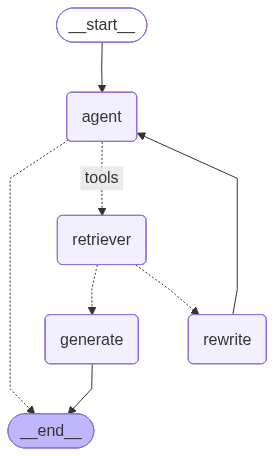

In [135]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
graph.invoke({"messages": "What is langgraph?"})

------CALL AGENT-------
----Check Relevence-----
--------DECISION: DOCS RELEVANT--------
-----GENERATE--------


{'messages': [HumanMessage(content='What is langgraph?', additional_kwargs={}, response_metadata={}, id='990aafcb-341e-4da9-a166-cafac564cd87'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking, "What is langgraph?" Let me think about how to approach this.\n\nFirst, I need to determine which tool to use. The available tools are for searching information about Langgraph and Langchain. Since the user specifically mentioned "langgraph," the correct function would be retriever_vector_db_blog. The other function is for langchain, which isn\'t what\'s being asked here.\n\nNext, I should structure the query. The function requires a "query" parameter. The user\'s question is straightforward, so the query should be something like "What is langgraph?" to retrieve relevant information. I need to make sure the arguments are correctly formatted as a JSON object within the tool_call tags.\n\nWait, should I check if there\'s any ambiguity? The user didn\'t men

In [144]:
graph.invoke({"messages": "How does langgraph related to tajmahal?"})

------CALL AGENT-------
----Check Relevence-----
--------DECISION: DOCS NOT RELEVANT----------
no
----TRANSFORM QUERY-------
------CALL AGENT-------


{'messages': [HumanMessage(content='How does langgraph related to tajmahal?', additional_kwargs={}, response_metadata={}, id='3187200f-c3dd-4166-be7c-315983a51a5b'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, let\'s see. The user is asking how Langgraph relates to the Taj Mahal. First, I need to understand what each of these terms refers to.\n\nLanggraph is a framework I\'m familiar with, probably related to language models or graph structures. The Taj Mahal is a famous historical monument in India. At first glance, they seem unrelated—one is a technological tool, the other a piece of architecture.\n\nBut the user is asking for a connection. Maybe there\'s a metaphor or an analogy they\'re thinking of. Or perhaps they heard something about using Langgraph in a project related to the Taj Mahal. Without more context, it\'s hard to say.\n\nI should check if there\'s existing information linking them. Let me use the available tools. The retriever_vector_db_blog 